# 임베딩 의미 정합성 탐색

**목적**: ccomantle 의 임베딩 사전이 사용자 의미 직관과 얼마나 일치하는지 탐색.
정답 단어를 바꿔가며 top N 결과를 보고 "이상한 case" 식별.

**왜 ipynb?** 도구 단계 (script/PR) 들어가기 전 탐색·spot-check 단계. 빠르게 정답 바꾸면서 결과 보고 패턴 식별 → 그 위에 정량 측정 (KorLex Golden 등) 설계.

**연결 docs**:
- 본 PR 의 상위 design: `docs/features/05_evaluation_methodology.md` §3 (placeholder)
- 메인 strategy: `~/GitStudy/make_portfolio/지원/anna/평가전략_종합.md` §4.3 임베딩 자체 검증

---

## 사용법
1. 각 cell 순차 실행 (Shift+Enter)
2. `ANSWER` 변수 바꿔가며 다양한 정답 시도
3. 표 보면서 "왜 이게 여기 있지?" spot-check
4. 발견 사항 markdown cell 에 인라인 메모
5. 패턴 식별되면 그게 다음 PR 트랙 입력

## 1. Setup — 임베딩 로드

In [ ]:
import json
from pathlib import Path
import numpy as np

# repo root 자동 탐지 (cwd 가 notebooks/ 이든 repo root 이든 작동)
REPO_ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents)
                 if (p / 'data' / 'embedding_dictionary_e5.json').exists())
EMB_PATH = REPO_ROOT / 'data' / 'embedding_dictionary_e5.json'

print(f'load: {EMB_PATH}')
with open(EMB_PATH, 'rb') as f:
    emb_dict = json.loads(f.read())

words = list(emb_dict.keys())
matrix = np.array([emb_dict[w] for w in words], dtype=np.float32)
# L2 정규화 (보통 이미 돼있지만 안전하게)
norms = np.linalg.norm(matrix, axis=1, keepdims=True)
norms[norms == 0] = 1.0
matrix = matrix / norms

word_to_idx = {w: i for i, w in enumerate(words)}
print(f'단어 수: {len(words):,}')
print(f'임베딩 shape: {matrix.shape}')
print(f'matrix dtype: {matrix.dtype}')

load: /Users/jun/GitStudy/ccomantle/data/embedding_dictionary_e5.json
단어 수: 60,000
임베딩 shape: (60000, 1024)
matrix dtype: float32


In [7]:
import pltfont
pltfont.auto()

✅ 현재 폰트 적용됨: Arial Unicode MS


## 2. Helper — 정답 단어에 대한 top N 출력

In [8]:
def top_n_for(answer: str, n: int = 50, exclude_self: bool = True) -> list[tuple[str, float, int]]:
    """정답 단어와 cosine 유사도 top N 단어 반환.

    Returns: [(word, similarity, rank), ...] — rank 는 1-indexed 전체 순위
    """
    if answer not in word_to_idx:
        raise KeyError(f'사전에 없는 단어: {answer!r}')
    vec = matrix[word_to_idx[answer]]
    sims = matrix @ vec  # (N,)
    order = np.argsort(-sims)
    out = []
    skip_first = 1 if exclude_self else 0
    for rank_idx, idx in enumerate(order[skip_first:skip_first + n], 1):
        out.append((words[idx], float(sims[idx]), rank_idx))
    return out

def print_top(answer: str, n: int = 50) -> None:
    print(f'=== 정답 "{answer}" — top {n} ===')
    print(f'{"rank":>4}  {"word":<12}  {"cosine":>8}')
    for w, s, r in top_n_for(answer, n):
        print(f'{r:>4}  {w:<12}  {s:>8.4f}')

def compare_pair(a: str, b: str) -> float:
    """두 단어의 cosine 유사도."""
    va = matrix[word_to_idx[a]]
    vb = matrix[word_to_idx[b]]
    return float(va @ vb)

# 작동 확인
print(f'사과 ↔ 배: {compare_pair("사과", "배"):.4f}')
print(f'사과 ↔ 자동차: {compare_pair("사과", "자동차"):.4f} (사과 보다 멀어야 정상)')

사과 ↔ 배: 0.1239
사과 ↔ 자동차: 0.1668 (사과 보다 멀어야 정상)


## 3. 단일 정답 탐색 — 이 cell 의 `ANSWER` 변경하면서 반복

**관찰 가이드**:
- 의미적으로 가까운 단어가 진짜 상위에 있나?
- "왜 이게 여기 있지?" 싶은 단어 어떤 게 있나?
- 같은 도메인 (과일·동물·감정 등) 단어가 cluster 되어 있나?
- 활용형/유사 표기 같이 묶여있나? (예: "기쁨"·"기뻐함" 같이 등장)

In [9]:
ANSWER = '사과'
TOP_N = 50

print_top(ANSWER, TOP_N)

=== 정답 "사과" — top 50 ===
rank  word            cosine
   1  사과와             0.7390
   2  사과는             0.6446
   3  사과가             0.6373
   4  사과의             0.5365
   5  설과              0.5316
   6  사과를             0.5247
   7  제과              0.5071
   8  인과              0.5049
   9  사이다             0.5040
  10  여과              0.4870
  11  무과              0.4508
  12  사바              0.4441
  13  신과              0.4344
  14  사사              0.4294
  15  안과              0.4195
  16  내과              0.4179
  17  사실과             0.4161
  18  일과              0.4031
  19  사람과             0.4024
  20  정과              0.3969
  21  세금과             0.3957
  22  씨와              0.3950
  23  시와              0.3941
  24  문과              0.3921
  25  법과              0.3916
  26  글과              0.3837
  27  사상과             0.3824
  28  적과              0.3816
  29  교과              0.3808
  30  빵과              0.3787
  31  상과              0.3787
  32  사자              0.3785
  33  왕과          

### 발견 사항 — "사과" (사용자가 채움)

- (예시) 1위: ___
- 이상하게 높은 단어: ___
- 예상한 단어가 너무 낮음: ___
- 패턴: ___

## 4. 다양한 정답 일괄 비교 — 도메인별 패턴 식별

여러 정답의 top 20 만 짧게 출력해 도메인별 결을 한 번에 비교.

In [10]:
# 도메인별 sampling — 자유롭게 추가/수정
ANSWERS = [
    '사과',   # 과일
    '배',     # 과일 (동음이의 있음 — 신체/배 vs 과일 vs 선박)
    '강아지', # 동물
    '집',     # 사물
    '사랑',   # 추상 (감정)
    '학교',   # 장소
    '차',     # 사물 (동음이의 — 자동차/녹차)
    '비',     # 자연 (동음이의 — 비/빗자루)
]

MISSING = [a for a in ANSWERS if a not in word_to_idx]
if MISSING:
    print(f'⚠️ 사전에 없음: {MISSING}\n')

for ans in ANSWERS:
    if ans in MISSING:
        continue
    print(f'\n--- "{ans}" top 20 ---')
    for w, s, r in top_n_for(ans, 20):
        print(f'  {r:>2}. {w:<10} {s:.4f}')

⚠️ 사전에 없음: ['비']


--- "사과" top 20 ---
   1. 사과와        0.7390
   2. 사과는        0.6446
   3. 사과가        0.6373
   4. 사과의        0.5365
   5. 설과         0.5316
   6. 사과를        0.5247
   7. 제과         0.5071
   8. 인과         0.5049
   9. 사이다        0.5040
  10. 여과         0.4870
  11. 무과         0.4508
  12. 사바         0.4441
  13. 신과         0.4344
  14. 사사         0.4294
  15. 안과         0.4195
  16. 내과         0.4179
  17. 사실과        0.4161
  18. 일과         0.4031
  19. 사람과        0.4024
  20. 정과         0.3969

--- "배" top 20 ---
   1. 배장         0.9352
   2. 배압         0.9189
   3. 배부         0.9188
   4. 차          0.9175
   5. 윗배         0.9173
   6. 아랫배        0.9164
   7. 배나무        0.9158
   8. 뱀          0.9149
   9. 빵          0.9148
  10. 배란         0.9140
  11. 배암         0.9124
  12. 책          0.9115
  13. 배앓이        0.9114
  14. 배엽         0.9112
  15. 밤          0.9108
  16. 병          0.9086
  17. 뇌          0.9080
  18. 배질         0.9075
  19. 패패         0.9068
  20.

### 발견 사항 — 도메인 비교 (사용자가 채움)

- 동음이의어 처리: ___
- 도메인 cluster 작동? : ___
- 추상명사 ("사랑") 가 명사 well-clustered: ___
- 활용형 의심 ("-하다" 끝 단어가 정답에 자주 나옴): ___

## 5. 의미 카테고리 cross-check

특정 정답에 대해 "기대 카테고리" 단어의 순위·점수가 어디인지 확인.
예: 정답 "사과" 에 대해 다른 과일들이 몇 위에 있는가?

In [11]:
def rank_of(answer: str, candidates: list[str]) -> list[tuple[str, int, float]]:
    """answer 의 sim 순위에서 candidates 각각의 rank + sim."""
    if answer not in word_to_idx:
        raise KeyError(answer)
    vec = matrix[word_to_idx[answer]]
    sims = matrix @ vec
    order = np.argsort(-sims)
    rank_map = {words[idx]: r for r, idx in enumerate(order, 1)}
    out = []
    for c in candidates:
        if c not in word_to_idx:
            out.append((c, -1, float('nan')))
            continue
        r = rank_map[c]
        s = float(sims[word_to_idx[c]])
        out.append((c, r, s))
    return out

# 예시: 정답 "사과" 에 대해 과일들의 위치
ANSWER = '사과'
EXPECTED_DOMAIN = ['배', '포도', '바나나', '딸기', '수박', '망고', '레몬', '복숭아']

print(f'정답 "{ANSWER}" 에서 기대 카테고리(과일) 각 단어의 순위·점수:\n')
print(f'{"word":<10} {"rank":>8} {"cosine":>10}')
for w, r, s in rank_of(ANSWER, EXPECTED_DOMAIN):
    rank_str = '없음' if r < 0 else f'{r:>8,}'
    sim_str = '-' if s != s else f'{s:>10.4f}'
    print(f'{w:<10} {rank_str:>8} {sim_str:>10}')

정답 "사과" 에서 기대 카테고리(과일) 각 단어의 순위·점수:

word           rank     cosine
배             3,888     0.1239
포도              737     0.2234
바나나             125     0.3092
딸기            2,316     0.1556
수박              992     0.2057
망고            1,859     0.1687
레몬            1,574     0.1793
복숭아           1,270     0.1915


### 발견 사항 — 도메인 정합성 (사용자가 채움)

- 과일들이 다 top 100 안에 들어왔나? : ___
- 안 들어온 단어 어떤 것? : ___
- cosine 값들 자연스러운가 (의미 가까울수록 높나)? : ___

## 6. (선택) cosine 분포 시각화

matplotlib 설치돼 있으면 분포 hist 로 패턴 확인.

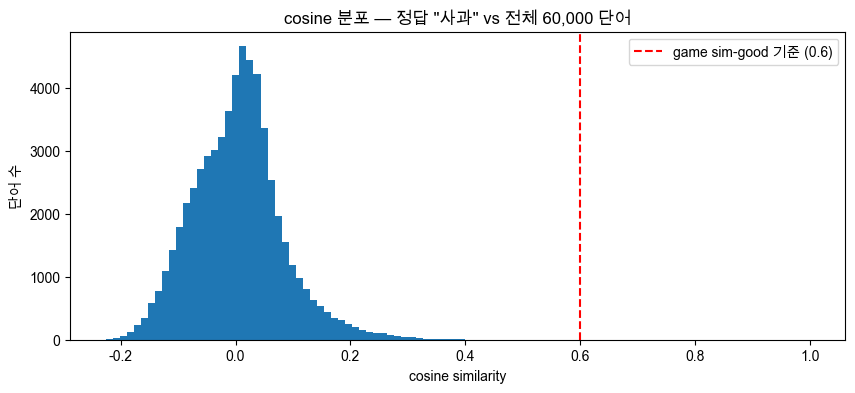

mean: 0.0040, std: 0.0790
min: -0.2264, max: 1.0000
>= 0.6 인 단어 수: 4
>= 0.7 인 단어 수: 2


In [12]:
ANSWER = '사과'

try:
    import matplotlib.pyplot as plt
    vec = matrix[word_to_idx[ANSWER]]
    sims = matrix @ vec
    plt.figure(figsize=(10, 4))
    plt.hist(sims, bins=100)
    plt.title(f'cosine 분포 — 정답 "{ANSWER}" vs 전체 {len(words):,} 단어')
    plt.xlabel('cosine similarity')
    plt.ylabel('단어 수')
    plt.axvline(0.6, color='red', linestyle='--', label='game sim-good 기준 (0.6)')
    plt.legend()
    plt.show()
    print(f'mean: {sims.mean():.4f}, std: {sims.std():.4f}')
    print(f'min: {sims.min():.4f}, max: {sims.max():.4f}')
    print(f'>= 0.6 인 단어 수: {(sims >= 0.6).sum():,}')
    print(f'>= 0.7 인 단어 수: {(sims >= 0.7).sum():,}')
except ImportError:
    print('matplotlib 미설치. pip install matplotlib 후 재실행.')

## 7. 종합 발견 — 다음 PR 결정 입력 (사용자가 채움)

위 §3-§6 의 spot-check 결과 기반:

### 7.1 가장 큰 문제 패턴
- (예시) 활용형이 top 안에 너무 많이 나옴 → 동의어/활용형 클러스터링 필요
- (예시) 동음이의어 ("배"·"차") 가 의미 분리 안 됨 → 임베딩 모델 한계
- (예시) cosine 분포가 너무 좁음 (mean 0.5+) → mean centering 강화 필요
- (예시) 특정 도메인이 약함 (감정·추상명사) → 임베딩 모델 의존

### 7.2 다음 PR 후보 (handoff 의 트랙 중 선택)
- [ ] `feat/sim-calibration` — sim_alpha / 1000위=0.63 target 재검토
- [ ] `feat/embedding-model-comparison` — multilingual-e5-large vs KoE5 vs KURE 비교
- [ ] `feat/dict-cleanup-activations` — 활용형 클러스터링 (관련 패턴 발견 시)
- [ ] `feat/embedding-intrinsic-eval` — KorLex Golden 정량 평가 (외부 dataset 다운로드 필요)

### 7.3 새 발견 (위에 없는 패턴)
- ___